In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score
import warnings
warnings.filterwarnings('ignore')

## Load & Preprocess

In [2]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
df = df.drop(columns=['duration'])
df['y'] = (df['y'] == 'yes').astype(int)
df = pd.get_dummies(df, drop_first=True)

X = df.drop(columns=['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train, _, y_train, _ = train_test_split(X_train, y_train, train_size=0.3, stratify=y_train, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (9885, 52)  Test: (8238, 52)


## 1 — Linear SVM (C=1)

In [3]:
svm = SVC(kernel='linear', C=1.0, random_state=42)
svm.fit(X_train, y_train)
print(classification_report(y_test, svm.predict(X_test), target_names=['No','Yes']))

              precision    recall  f1-score   support

          No       0.91      0.99      0.94      7310
         Yes       0.65      0.20      0.31       928

    accuracy                           0.90      8238
   macro avg       0.78      0.59      0.63      8238
weighted avg       0.88      0.90      0.87      8238



## 2 — Tune C, report optimal, plot margin

Optimal C: 0.01 (default is 1.0)


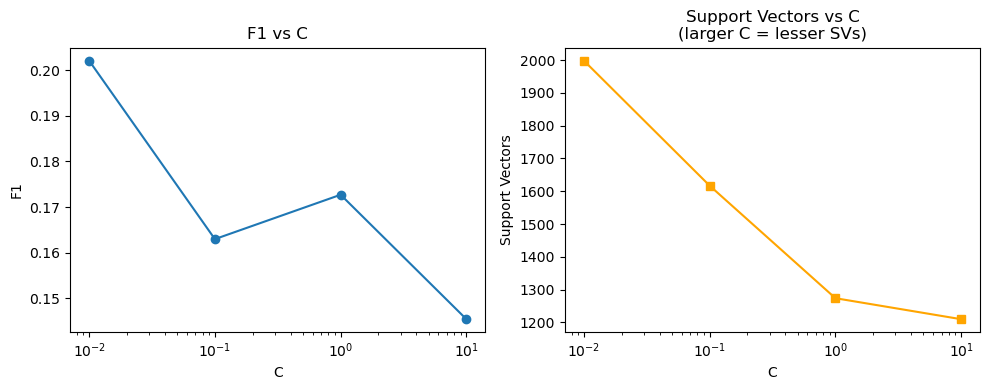

In [4]:
C_values = [0.01, 0.1, 1.0, 10.0]
f1_scores, sv_counts = [], []

for c in C_values:
    m = SVC(kernel='linear', C=c, max_iter=1000, random_state=42).fit(X_train, y_train)
    f1_scores.append(f1_score(y_test, m.predict(X_test)))
    sv_counts.append(m.n_support_.sum())

optimal_C = C_values[np.argmax(f1_scores)]
print(f'Optimal C: {optimal_C} (default is 1.0)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].semilogx(C_values, f1_scores, 'o-')
axes[0].set_title('F1 vs C'); axes[0].set_xlabel('C'); axes[0].set_ylabel('F1')
axes[1].semilogx(C_values, sv_counts, 's-', color='orange')
axes[1].set_title('Support Vectors vs C\n(larger C = lesser SVs)')
axes[1].set_xlabel('C'); axes[1].set_ylabel('Support Vectors')
plt.tight_layout(); plt.show()

## 3 — RBF and Polynomial kernel, hyperparameter tuning

In [5]:
# RBF
grid_rbf = GridSearchCV(SVC(kernel='rbf', random_state=42),
    {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1]},
    cv=3, scoring='f1', n_jobs=-1)
grid_rbf.fit(X_train, y_train)
print('Best RBF Parameters:', grid_rbf.best_params_)
print(classification_report(y_test, grid_rbf.best_estimator_.predict(X_test), target_names=['No','Yes']))

Best RBF Parameters: {'C': 10, 'gamma': 'scale'}
              precision    recall  f1-score   support

          No       0.91      0.97      0.94      7310
         Yes       0.52      0.25      0.34       928

    accuracy                           0.89      8238
   macro avg       0.72      0.61      0.64      8238
weighted avg       0.87      0.89      0.87      8238



In [6]:
# Polynomial
grid_poly = GridSearchCV(SVC(kernel='poly', random_state=42),
    {'C': [0.1, 1, 10], 'degree': [2, 3, 4]},
    cv=3, scoring='f1', n_jobs=-1)
grid_poly.fit(X_train, y_train)
print('Best params:', grid_poly.best_params_)
print(classification_report(y_test, grid_poly.best_estimator_.predict(X_test), target_names=['No','Yes']))

Best params: {'C': 10, 'degree': 3}
              precision    recall  f1-score   support

          No       0.91      0.96      0.94      7310
         Yes       0.47      0.27      0.34       928

    accuracy                           0.88      8238
   macro avg       0.69      0.62      0.64      8238
weighted avg       0.86      0.88      0.87      8238



## Task 4 — Support vectors for best model

In [7]:
best = grid_rbf.best_estimator_
print(f'Total support vectors: {best.n_support_.sum()}')
print(f'Per class (No, Yes):   {best.n_support_}')
print()
print('Support vectors is clsoest to the decision boundary.',
      'These points decide the hyperplane position.',
      'Other training points dont effect the model.')

Total support vectors: 3374
Per class (No, Yes):   [2312 1062]

Support vectors is clsoest to the decision boundary. These points decide the hyperplane position. Other training points dont effect the model.


## Task 5 — Handle class imbalance

In [8]:
# Method: class weight is balanced
# Automatically allocates more weight to minority class for bigger penalisation in misclassification, didnt require synthetic.

svm_bal = SVC(kernel='rbf',
              C=grid_rbf.best_params_['C'],
              gamma=grid_rbf.best_params_['gamma'],
              class_weight='balanced',
              random_state=42)
svm_bal.fit(X_train, y_train)
print('class_weight=balanced:')
print(classification_report(y_test, svm_bal.predict(X_test), target_names=['No','Yes']))

class_weight=balanced:
              precision    recall  f1-score   support

          No       0.92      0.86      0.89      7310
         Yes       0.29      0.43      0.35       928

    accuracy                           0.81      8238
   macro avg       0.61      0.65      0.62      8238
weighted avg       0.85      0.81      0.83      8238

